<a href="https://colab.research.google.com/github/Text-Machine/mask-predict/blob/main/chr-paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> </a>

# CHR Paper notebook

This notebook aims to reproduce all figures and tables that inform the analysis of the CHR paper.

In [4]:
!git clone https://github.com/Text-Machine/mask-predict.git

fatal: destination path 'mask-predict' already exists and is not an empty directory.


In [ ]:
%cd mask-predict

In [ ]:
!pip install -q -e .

In [5]:
import pandas as pd
import json
from tqdm import tqdm
from explain import *
from pathlib import Path
from collections import Counter
import seaborn as sns

In [ ]:
%cd /content

In [ ]:
!gdown 125wfZ1P9MfFZ19XS2SCfallsnoNhLCUf

In [ ]:
!unzip -o "chr-data.zip"

In [6]:
collection,genre_suffix = 'blb',''
if collection == 'blb':
  genre_suffix = '_with_genre'

TargetMaskedToken = 'machine' # the token to be masked in the target sentence
try:
  import google.colab
  originalFolder = '.' # change to '.' when working in colab
  dataPath = '.' # change to '.' when working in colab 
  processedFolder = '.' # change '.' when working in colab
except:
  originalFolder = 'masking_data' # change to '.' when working in colab
  dataPath = 'input_data' # change to '.' when working in colab 
  processedFolder = 'gradient_data' # change '.' when working in colab

predCol = "pred_bert_1760_1900"
resultType = 'pred_kw_filtered' # pred | pred_kw_filter

print(f"This analysis focuses on '{TargetMaskedToken}'.")

This analysis focuses on 'machine'.


We are loading the data frame with deduplicated sentences.

In [23]:
df_sent_all = pd.read_csv(f'{originalFolder}/{collection}_{TargetMaskedToken}_clusters{genre_suffix}_deduplicated.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent_all.shape[0]} unique sentences for the target token {TargetMaskedToken} in the {collection} collection.')


We have 77907 unique sentences for the target token machine in the blb collection.


In [7]:
# load the original sentences with the predicted tokens
df_sent = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}{genre_suffix}_{resultType}.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent.shape[0]} sentences that produced human predictions for the target token {TargetMaskedToken} in the {collection} collection.')
df_ig = pd.read_csv(f'{processedFolder}/results_{collection}_{TargetMaskedToken}_{resultType}_processed.csv', index_col=0 )
print(f'We have {df_ig.shape[0]} explanations for the target token {TargetMaskedToken} in the {collection} collection.')


We have 19003 sentences that produced human predictions for the target token machine in the blb collection.
We have 2173047 explanations for the target token machine in the blb collection.


Here we load the words that we selected as human prediction, i.e. these are words predicted by BLERT possible referring to human fillers for the masked machine token.

In [25]:
with open(f'{dataPath}/250_freq_pred_KB_edit.txt') as f:
    human_words = f.read().splitlines()

print(human_words[:10])

['man', 'men', 'woman', 'child', 'people', 'person', 'hands', 'boy', 'girl', 'children']


We create a new column where filter the prediction, only retaining the human words.

In [26]:
for colName in ['pred_bert_contemporary', 'pred_bert_1760_1900']:
    df_sent[f'{colName}_human'] = df_sent[colName].apply(
        lambda x: {w:s for w, s in dict(eval(x)).items() if w in human_words})


We look at results by decade, therefore adding decade column to the data frames

In [27]:
df_sent_all['decade'] = df_sent_all['date'].apply(lambda x: int(x/10)*10)
df_sent['decade'] = df_sent['date'].apply(lambda x: int(x/10)*10)

### Analysis: Distribution of predictions

BLERT is not always equally convinced of it's predictions. Below we plot the distribution of it confidence scores for the human words it predicted instead of machine. These are the probabilities that a word fits the given context in the position of the masked token. We see that 

Distribution of the human prediction scores for the target token '{TargetMaskedToken}' in the {collection} collection.


<Axes: >

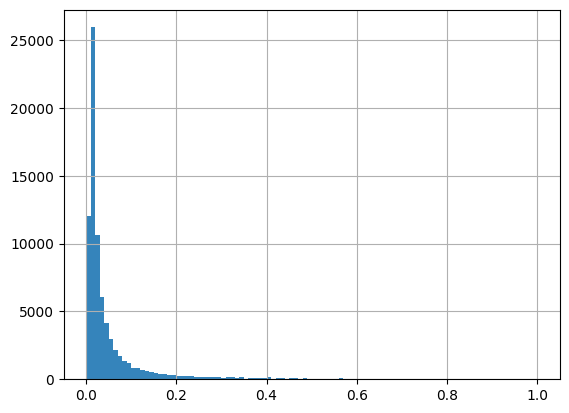

In [28]:
import itertools
scores_human = list(itertools.chain.from_iterable(df_sent['pred_bert_1760_1900_human'].apply(lambda x: list(x.values()))))
scores_all = list(itertools.chain.from_iterable(df_sent['pred_bert_1760_1900'].apply(lambda x: list(dict(eval(x)).values()))))

print("Distribution of the human prediction scores for the target token '{TargetMaskedToken}' in the {collection} collection.")
#pd.Series(scores_human).plot(kind='density')
pd.Series(scores_human).hist(bins=100, alpha=0.9, label='human predictions')
#pd.Series(scores_all).plot(kind='density', alpha=0.5)


### Analysis: timeline for all predictions

Below we plot the number of unique sentences containing 'human' predictions for masked machine tokens. We plot by decade, for all the human predictions, higher than a set confidence threshold. 

While maybe not drastically, we observe a small rise in the relative number of 'atypical' sentences or 'atypical' language use.

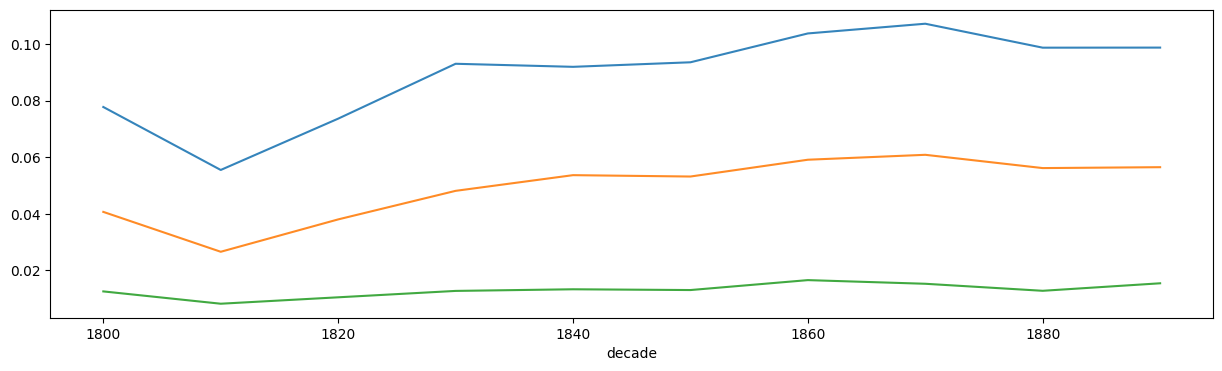

In [29]:
time_unit = 'decade' # change to 'date' for yearly analysis
thresholds = [0.1, 0.2, 0.5]
for threshold in thresholds:
    df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(lambda x: max(list(x.values())+[.0]) > threshold)]
    (df_sent_filtered.groupby(time_unit).size()/df_sent_all.groupby(time_unit).size()).loc[1800:1899].plot(alpha=0.9,
                                                                                                            title=f'', 
                                                                                                            xlabel=f'{time_unit}',
                                                                                                            figsize=(15, 4))


### Analysis: timeline for a selected thema

By changing the `wordList` variable below, we can plot timelines for specific subset or theme of predictions. 

The children theme shows a pronounced upward trend. This could be one of the subquestions we address in the paper: how and why the increasing confusion of child and machine?

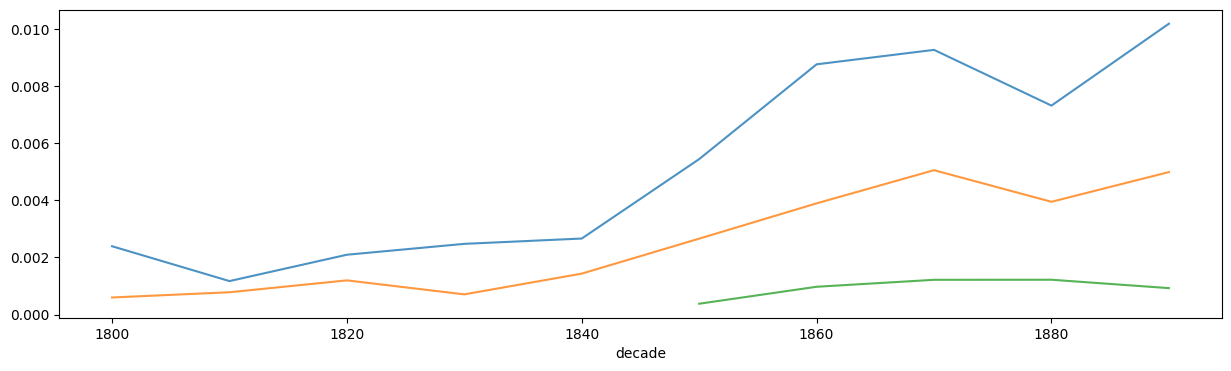

In [30]:
time_unit = 'decade' # change to 'date' for yearly analysis
thresholds = [ 0.1, 0.2, 0.5] # compare the results for different thresholds to see how the results change based on the confidence in the predictions
wordList = ['child','children', 'boy','boys','girl','girls']  # change these words to analyze a different theme
for threshold in thresholds:
    df_sent_filtered = df_sent[df_sent[f'{colName}_human'].apply(
        lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold
                )
            ]
    (df_sent_filtered.groupby(time_unit).size() / df_sent_all.groupby(time_unit).size()).loc[1800:1899].plot(alpha=0.8, 
                                                                                                             title=f'',
                                                                                                               xlabel=f'{time_unit}',
                                                                                                               figsize=(15, 4))


### Analysis: results by genre

The results hold when splitting the data by genre. Upward trend appears in both fiction and non-fiction but, more articulate in the form}er.

<Axes: xlabel='decade', ylabel='0'>

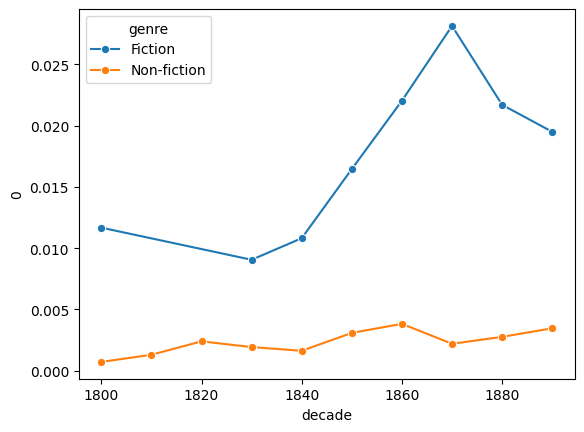

In [31]:

time_unit = 'decade' # change to 'date' for yearly analysis
threshold = 0.1 # use higher thresholds for more conservative analysis, i.e. only sentences with a high probability of the tokens in wordList being predicted are included in the analysis
wordList = ['child','children', 'boy','boys','girl','girls'] # change these words to analyze a different theme

df_sent_filtered = df_sent[df_sent['pred_bert_1760_1900_human'].apply(lambda x: max(list({w:s for w,s in x.items() if w in wordList}.values())+[.0]) > threshold)]
plot_df = df_sent_filtered.groupby([time_unit, 'genre']).size() / df_sent_all.groupby([time_unit, 'genre']).size()
plot_df_rel = (df_sent_filtered.groupby([time_unit, 'genre']).size() / df_sent_all.groupby([time_unit, 'genre']).size()).reset_index()
sns.lineplot(data=plot_df_rel, x=time_unit, y=0, hue='genre', marker='o')

### Analysis: Distribution of prediction

Which human words does BLERT predict instead of ''machine''? And why? 

We refined the analysis below by allowing to refine the threshold, i.e. to focus only on "confident" predictions etc.

In [32]:

thresholds = 0.1 # change this threshold to see how the results change based on the confidence in the predictions


In [33]:
df_sent_filtered = df_sent[df_sent[f'{colName}_human'].apply(lambda x: max(list(x.values())+[.0]) > threshold)]
preds = Counter([w for l in df_sent_filtered[f'{colName}'].values for w,s in eval(l) if (w in human_words) & (s > threshold) ])

<Axes: title={'center': 'Top 100 predicted tokens for the target token machine.'}, xlabel='Predicted token', ylabel='Count'>

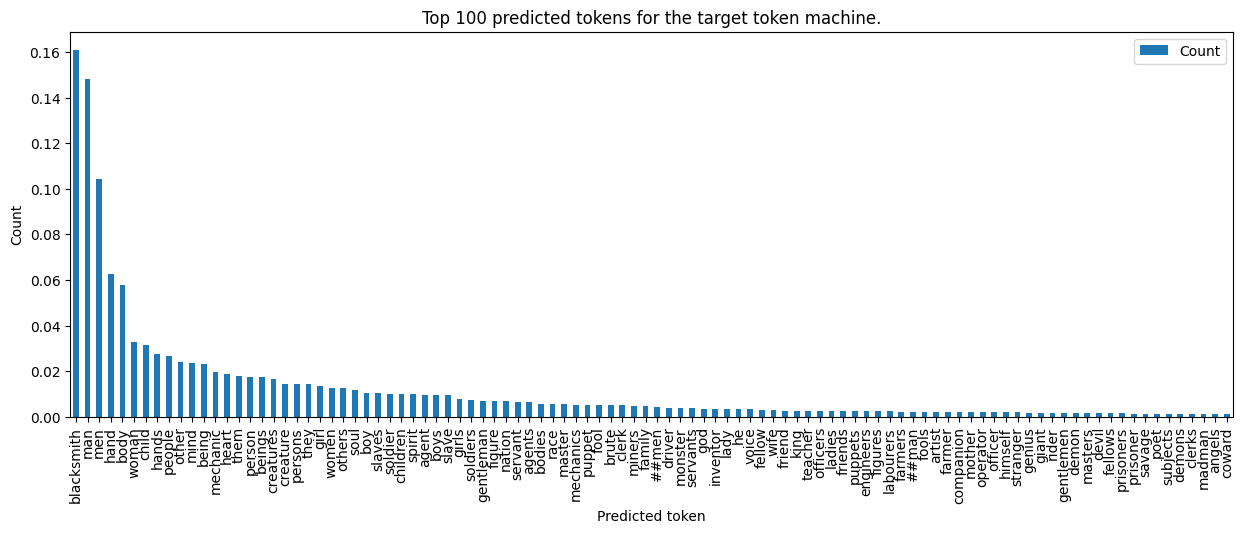

In [34]:
pd.DataFrame([(w, c/len(df_sent_filtered)) for w, c in preds.most_common(100)]
             ).rename(columns={0: 'Predicted token', 1: 'Count'}
                      ).set_index('Predicted token'
                                  ).plot(kind='bar', title=f'Top 100 predicted tokens for the target token {TargetMaskedToken}.', 
                                         ylabel='Count', xlabel='Predicted token', figsize=(15,5))

### Analysis: explainability

Which words drive the predictions, and especially, how to interpet this increasing "confusion" or children with machines? What does it tell us about changes in the discourse about machines.

What we compute is not just how words contribute to the prediction, this tells us often more about what type of sentences are included in our data. We look at which words explain the difference between machine and human words, i.e. which words drive the prediction towards 'human' and away from 'machine'.

More technically, for each word in the sentence we compute pairwise differences between ''machine'' and ''human'' predictions (for the masked token) for each token in the sentence.

In [35]:
# Create row order within each id and Target
df_ig["row_idx"] = df_ig.groupby(["id", "Target"]).cumcount()

# Extract machine/machines scores
machine_scores = (
    df_ig[df_ig["Target"].isin(["machine", "machines"])]
    [["id", "row_idx", "Score_normalized"]]
    .rename(columns={"Score_normalized": "machine_score"})
)

# Match each row with the corresponding machine row
df_ig = df_ig.merge(
    machine_scores,
    on=["id", "row_idx"],
    how="left"
)

# Subtract
df_ig["diff"] = df_ig["Score_normalized"] - df_ig["machine_score"]

# Optional: remove helper column
df_ig.drop(columns=["row_idx", "machine_score"], inplace=True)

In [36]:
df_ig[(df_ig['id'] == 11)].Target.unique()

<ArrowStringArray>
['girl', 'machine']
Length: 2, dtype: str

In [37]:
df_ig[(df_ig['id'] == 11) & (df_ig['Target'].isin(['machine', 'machines']))][['Target', 'Score_normalized', 'diff']].head(3)

,Target,Score_normalized,diff
1474,machine,0.049453,0.0
1475,machine,0.038349,0.0
1476,machine,0.028908,0.0


In [38]:
df_ig[(df_ig['id'] == 11) & (df_ig['Target'].isin(['girl']))][['Target', 'Score_normalized', 'diff']].head(3)

,Target,Score_normalized,diff
1454,girl,0.018882,-0.030571
1455,girl,0.030576,-0.007773
1456,girl,0.033602,0.004694


## Analysis: Explanation scores across all human word predictions

Below is a general analysis, highlighting which context words explain the drifting aways of explanations from the machine.

The threshold, again, regulates, the confidence.

The `df_result` dataframe shows the words that exhibit the highest difference between machine and human words. Below we provide tools for analysing these words, and the sentences, in which they appear, in more depth.

In [39]:
threshold = 0.25


targetTokens = ['machine','machines'] # we look at the predictions for all the non machine words
df_comparisonConcept = df_ig[
    (~df_ig['Target'].isin(targetTokens)) & # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
    (df_ig['Target_score'].between(threshold, 1.0))
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_diff=('diff', 'mean'), avg_score=('Score_normalized', 'mean')
                    ).reset_index()


In [40]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 20
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_diff', ascending=False)
df_result.head(10)

,Token,count,identifiers,avg_diff,avg_score
6531,human,245,"{8708, 6661, 4614, 6662, 9223, 15365, 13322, 1...",0.018612,0.037350
5207,fellow,23,"{4864, 6664, 10380, 9495, 14748, 1695, 14626, ...",0.011999,0.018966
1000,animal,33,"{5638, 12555, 5261, 4495, 4762, 17949, 418, 12...",0.010887,0.037803
1003,animated,30,"{17544, 2571, 1936, 15250, 17685, 9370, 13467,...",0.010837,0.017095
5817,girls,23,"{18561, 18562, 15006, 18337, 5666, 12070, 4263...",0.010800,0.023239
13693,various,40,"{13313, 16899, 4487, 11528, 6538, 6796, 16141,...",0.009001,0.015110
10039,printed,20,"{16257, 13443, 261, 16784, 6294, 6167, 12952, ...",0.008363,0.019711
12271,stood,27,"{16257, 6412, 9621, 18326, 11033, 9628, 15517,...",0.007890,0.010298
1937,bodies,23,"{16135, 1299, 5783, 12073, 4522, 4913, 10929, ...",0.007619,0.029765
10241,pulse,60,"{4352, 17536, 6787, 16646, 9223, 16917, 278, 3...",0.007309,0.004828


## Analysis: Explanation scores for a specific theme


The code below, repeats the contextual analyis, but focussing on specific theme, defined by the `comparisonTokens` variable. Here we highlight which context words explain the drifting aways of explanations from the machine, with regard to a specific theme.

The `threshold`  regulates, the confidence.

`comarisonTokens` defines a set of words which we compare against machine predictions.

The `df_result` dataframe shows the words that exhibit the highest difference between machine and human words. Below we provide tools for analysing these words, and the sentences, in which they appear, in more depth.

In [41]:


comparisonTokens = ['child','children', 'boy','boys','girl','girls']

df_comparisonConcept = df_ig[
    (df_ig['Target'].isin(comparisonTokens)) & \
    (df_ig['Target_score'].between(0.1, 1.0)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_diff=('diff', 'mean'), avg_score=('Score_normalized', 'mean')
                    ).reset_index()


In [42]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 20
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_diff', ascending=False)
df_result.head(10)

,Token,count,identifiers,avg_diff,avg_score
1637,girls,33,"{18561, 18562, 663, 18337, 4263, 15145, 16687,...",0.014579,0.026308
557,boys,24,"{4161, 9051, 11107, 13156, 4997, 14680, 4263, ...",0.009306,0.027787
3940,two,24,"{12160, 2, 16780, 15898, 13224, 17449, 4652, 3...",0.006471,0.012770
10,.,779,"{2, 6, 28, 18462, 10271, 18465, 18466, 6184, 2...",0.004541,0.007323
2191,little,62,"{18692, 5385, 10391, 14103, 5275, 11808, 18465...",0.004172,0.015105
449,been,68,"{10369, 17921, 15491, 5764, 13704, 13705, 1754...",0.003428,0.004522
3437,small,20,"{12568, 15075, 1317, 6, 15558, 15787, 8781, 60...",0.003271,0.013463
556,boy,25,"{6, 5385, 3085, 16795, 7836, 5541, 12201, 1450...",0.002811,0.018611
731,children,28,"{774, 4999, 13704, 15898, 2203, 295, 1320, 151...",0.002591,0.016153
613,by,148,"{3072, 11267, 4628, 2583, 15898, 7717, 2090, 1...",0.002271,0.004472


In [43]:
#df_result.avg_score.plot(kind='hist', bins=100, title=f'Histogram of average scores for tokens predictive of the contrastive concept.', xlabel='Average score', ylabel='Count')

# Analysis: Zooming in on sentences based on context words

You can zoom in a sentences with using the predictive context words. Change the `id` variable below with one of the index numbers of the`df_result` dataframe.

The sentence are ranked, with examples where the context word obtains the highest scores, first.

You can change the following variable:

- `id` selected from the `df_result` dataframe
- `sort_value` how do sort the sentences, i.e. where the impact of the target word is thelargest ('Score_normalized') or makes the biggest difference ('diff')

In [44]:
pd.set_option('display.max_colwidth', 200)

In [45]:
id = 1637
sort_value = 'diff' #'Score_normalized' | 'diff'


identifiers_ranked = df_ig.loc[df_ig['id'].isin(list(df_result.loc[id].identifiers)) \
                             & (df_ig['Token']==df_result.loc[id].Token) \
                             & df_ig['Target'].isin(comparisonTokens)
                             
                             ].sort_values(by=sort_value, ascending=False)['id'].unique()
sentences_ranked = df_sent.iloc[list(identifiers_ranked)].head(20)
sentences_ranked.currentSentence

11509                                              From this small beginning he has continued to in crease his machinery, till he has thirty five machines, and in the busy season he employs twenty five girls.
15200                                                                   " Ten seams of equal length were prepared for sewing, of which five were laid by the machine and the other five were given to the girls.
8147                                                                       The machines are tended by Mestiza girls, who are very neat at their work, going about quietly and without even singing or whistling.
18337                                                                        After the leather has been cut, it is sent into the sewing room, where sixty girls, and a similar number of machines, are employed.
18562    After this the girls were taken down some stairs into a long room where large machines were working on wheels and straps; a great length of the very finest

In [46]:
# Optional: save and expeort sentences
name = 'child'
outPath = Path('sentences')
outPath.mkdir(exist_ok=True)
sentences_ranked.to_csv(outPath / f'{name}_sentences.csv', index=False)

In [8]:
modelName = "Livingwithmachines/bert_1760_1900"
explainer = MaskedLMExplainer(model_name=modelName, device=pick_device())

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Analysis: Inspect IG for one sentence

In [48]:
idx = 11509
target_token = 'predicted' # 'actual' | 'predicted'

sentence = df_sent.iloc[idx].maskedSentence

if target_token == 'actual':
    target_token = df_sent.iloc[idx].targetExpression
elif target_token == 'predicted':
    target_token =  [w for w, v in sorted(
       df_sent.iloc[idx].pred_bert_contemporary_human.items(), key=lambda x: x[1], reverse=True)
                     if w in wordList][0]
print(target_token)

boys


In [49]:

highlight_context_tokens(explainer, sentence, target=target_token, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_0faefae865b0475e84c61a286e9bf691">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>boys</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.043786\' style=\'background:rgba(30, 136, 229, 0.136); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>from</span> <span class=\'tok\' data-score=\'0.001377\' style=\'background:rgba(30, 136, 229, 0.101); padding:2px 4px; margin

## Inspect sentences based on Context and Predicted token

In [50]:
predictedToken = 'men'
contextToken = 'animal'
sort_value = 'diff' #'Score_normalized' | 'diff'

ids = df_ig[(df_ig['Token'].str.lower() == contextToken) & (df_ig['Target'].str.lower() == predictedToken)
                    ].sort_values(sort_value,ascending=False).id.values

In [51]:
idx = 4495
wordList = human_words
sentence = df_sent.iloc[idx].maskedSentence
targets = list(set(df_ig[df_ig['id'] == idx].Target.unique()).intersection(set(wordList)))
target_expression = df_sent.iloc[idx].targetExpression

In [52]:
print(f"Sentence: {sentence}")
print(f"Targets: {targets}")
print(f"Targets: {target_expression}")

Sentence: It has done much to convert these he Avers of Avood and drawers of Avater from reasoning creatures into animal [MASK] .
Targets: ['creatures', 'men', 'beings']
Targets: machines


In [53]:
#target =targets[0]

In [54]:

highlight_context_tokens(explainer, sentence, target=predictedToken, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_bd6ce0e2d15b4991bf1cc52db6fbbbda">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>men</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.142190\' style=\'background:rgba(30, 136, 229, 0.258); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>it</span> <span class=\'tok\' data-score=\'0.104104\' style=\'background:rgba(30, 136, 229, 0.216); padding:2px 4px; margin:1p

# Notebook still under construction here, please ignore or run at your own risk! :-)

## Historical Experiments

In [55]:
df_ig_merged = df_ig.merge(df_sent[['decade','date']], left_on='id',right_index=True, how='left')
df_ig.shape, df_ig_merged.shape

((2173047, 12), (2173047, 14))

<Axes: title={'center': 'Average diff in scores for tokens predictive of the contrastive concept over time.'}, xlabel='decade', ylabel='Average difference in scores'>

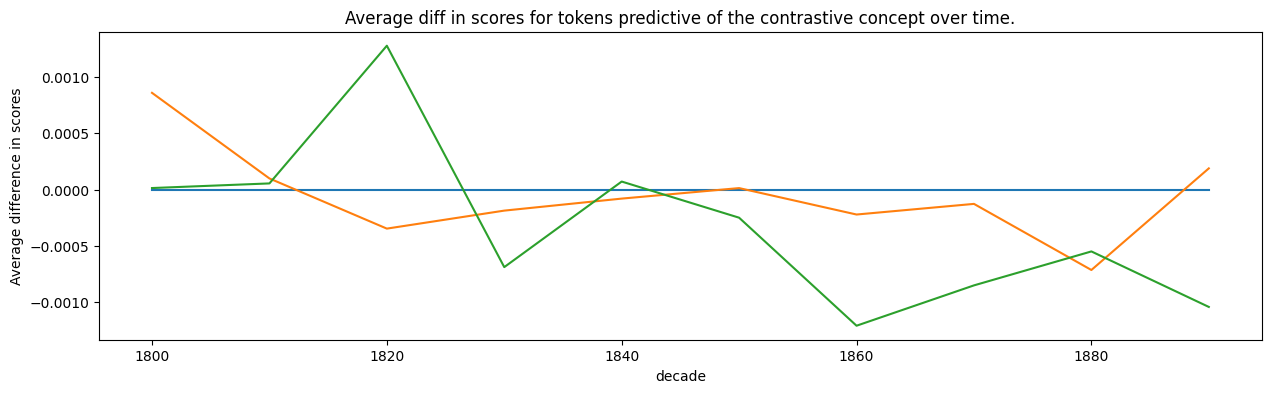

In [56]:
min_sentence_length = 20
max_sentence_length = 200   
min_confidence = .1
column_name = 'diff' # Score_normalized | diff

df_ig_merged[(df_ig_merged['Target'].isin(['machine','machines'])) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'].between(min_sentence_length, max_sentence_length))
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot(title=f'Average {column_name} in scores for tokens predictive of the contrastive concept over time.', xlabel='Decade', ylabel='Average difference in scores', figsize=(15, 4))

df_ig_merged[(~df_ig_merged['Target'].isin(['machine','machines'])) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'].between(min_sentence_length, max_sentence_length))
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot()

df_ig_merged[(df_ig_merged['Target'].isin(comparisonTokens)) & \
             (df_ig_merged['Target_score'].between(min_confidence,1.0)) & \
             (df_ig_merged['Sentence_length'].between(min_sentence_length, max_sentence_length))
             ].groupby(['decade','id'])[column_name].mean().groupby('decade').mean().loc[1800:1890].plot()

In [62]:
df_ig['sent_diff'] = df_ig.groupby('id')['diff'].transform(lambda x: x.mean())
df_ig['sent_diff'] = df_ig.groupby('id')['diff'].transform(lambda x: x.mean())
sent_diff_scores = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                          (df_ig['Target_score'].between(.1,1.0)) & \
                          (df_ig['Sentence_length'] > 20)
                          ].drop_duplicates(subset=['id'])['sent_diff']
#sent_diff_scores.plot(kind='hist', bins=100, title=f'Histogram of average difference in scores for tokens predictive of the contrastive concept.', xlabel='Average difference in scores', ylabel='Count')

<Axes: title={'center': 'Histogram of average difference in scores for tokens predictive of the contrastive concept.'}, xlabel='Average difference in scores', ylabel='Count'>

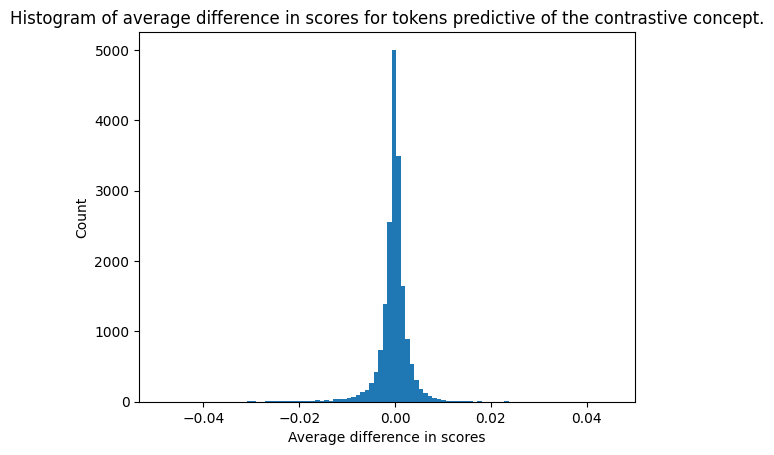

In [63]:
sent_diff_scores = df_ig[~df_ig['Target'].isin(['machine','machines'])].drop_duplicates(subset=['id'])['sent_diff']
sent_diff_scores.plot(kind='hist', bins=100, title=f'Histogram of average difference in scores for tokens predictive of the contrastive concept.', xlabel='Average difference in scores', ylabel='Count')

## Analysis: Sentences where we observe largest changes 

In [ ]:
min_confidence = .1
max_confidence = 1.0
min_sentence_length = 50
max_sentence_length = 200
n_examples = 1000

most_changes = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                      (df_ig['Target_score'].between(min_confidence, max_confidence)) & \
                      (df_ig['Sentence_length'].between(min_sentence_length, max_sentence_length))
                      ].sort_values(by='sent_diff', ascending=False)[['id','sent_diff','Target','Token']]['id'].unique()[:n_examples]

In [65]:
pd.set_option('display.max_colwidth', 200)
df_sel_sent = df_sent.iloc[most_changes]
df_sel_sent.currentSentence

5870                                               He might have been an evidence machine set to work mechanically7, and showering forth his testi mony at each turn of the wheel.
4751                        Day and night the machines kept at work, and on the morning of the 1 6th the thermometer had sunk to zero, and the water in the pipes was frozen hard.
7081                                                                                                                         Your machine, your body, must be thoroughly obedient.
14014      19 — 2 LOVICE 292 Louie, seeing that her duties are at last accom plished, draws her machine from the laurel bush against which it is reclining, and prepares to mount.
5084                                                               " Again, might not the glory of the machines consist in their being without this same boasted gift of language.
9628                                                                                     She came round o

In [68]:
min_confidence = .1
max_confidence = 1.0
min_sentence_length = 50
max_sentence_length = 200
n_examples = 1000

minimal_changes = df_ig[(~df_ig['Target'].isin(['machine','machines'])) & \
                      (df_ig['Target_score'].between(min_confidence, max_confidence)) & \
                      (df_ig['Sentence_length'].between(min_sentence_length, max_sentence_length)) & \
                      (df_ig['sent_diff'].between(-0.005,0.005))
                      ].sort_values(by='sent_diff', ascending=True)[['id','sent_diff','Target','Token']]['id'].unique()[:n_examples]

In [69]:
pd.set_option('display.max_colwidth', 200)
df_sel_sent = df_sent.iloc[most_changes]
df_sel_sent.currentSentence

5870                                               He might have been an evidence machine set to work mechanically7, and showering forth his testi mony at each turn of the wheel.
4751                        Day and night the machines kept at work, and on the morning of the 1 6th the thermometer had sunk to zero, and the water in the pipes was frozen hard.
7081                                                                                                                         Your machine, your body, must be thoroughly obedient.
14014      19 — 2 LOVICE 292 Louie, seeing that her duties are at last accom plished, draws her machine from the laurel bush against which it is reclining, and prepares to mount.
5084                                                               " Again, might not the glory of the machines consist in their being without this same boasted gift of language.
9628                                                                                     She came round o

In [84]:
idx = 17071 #15972
target_token = 'predicted' # 'actual' | 'predicted'

sentence = df_sent.iloc[idx].maskedSentence

if target_token == 'actual':
    target_token = df_sent.iloc[idx].targetExpression
elif target_token == 'predicted':
    target_token =  [w for w, v in sorted(
       df_sent.iloc[idx].pred_bert_contemporary_human.items(), key=lambda x: x[1], reverse=True)
                     if w in wordList][0]
print(target_token)

nation


In [85]:

highlight_context_tokens(explainer, sentence, target=target_token, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_59825ad098204bd8bc86dd6a7994fd67">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>nation</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.031942\' style=\'background:rgba(30, 136, 229, 0.162); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>39</span> <span class=\'tok\' data-score=\'0.389386\' style=\'background:rgba(30, 136, 229, 0.850); padding:2px 4px; margin

## qa: which predicted words change the context dependencies the least?

## Linear trends

In [ ]:
df_ig_by_token = df_ig_merged.groupby(['Token','decade'])['Score_normalized'].mean().reset_index()

In [61]:
words = [w for w,v in Counter(df_ig['Token']).items() if v > 100]

In [62]:
from sklearn.linear_model import LinearRegression
def get_linear_regression_slope(df, x_col='decade', y_col='Score_normalized'):
    X = df[[x_col]].values
    y = df[y_col].values
    model = LinearRegression()
    model.fit(X, y)
    return model.coef_[0] # Return the slope

In [ ]:
slopes = df_ig_by_token.groupby('Token').apply(lambda x: get_linear_regression_slope(x))
slopes.loc[words].sort_values(ascending=False)

In [ ]:
token = 'sewing'
df_ig_merged[df_ig_merged.Token==token].groupby('decade')['Score_normalized'].mean().plot(title=f'Average score for the token "{token}" over time.', xlabel='Decade', ylabel='Average score', figsize=(15, 4))

## Sentence t-SNE visualization

This section embeds sentences from a dataframe column, projects them to 2D with t-SNE, and renders an interactive Plotly visualization.

- `model_or_embedder`: embedding model, model name, `(model, tokenizer)` tuple, or an object with `model` and `tokenizer`
- `df`: input dataframe
- `text_column`: dataframe column used for sentence embeddings
- `hover_columns`: list of columns shown on hover
- `search_columns`: list of columns searched by the search box

In [1]:
import numpy as np

import pandas as pd

import plotly.graph_objects as go

import ipywidgets as widgets

import torch

from IPython.display import display, clear_output

from sklearn.manifold import TSNE

from transformers import AutoModel, AutoTokenizer



# TODO:

# - Cache sentence embeddings so search/reruns do not recompute the model pass.

# - Add an optional color/group column for comparing sentence subsets in one view.

# - Add optional PCA pre-reduction before t-SNE for larger datasets.

# - Add export of filtered rows or selected points from the interactive search UI.



def _get_base_encoder(model):

    if hasattr(model, "base_model") and model.base_model is not None:

        return model.base_model

    if hasattr(model, "bert") and model.bert is not None:

        return model.bert

    if hasattr(model, "roberta") and model.roberta is not None:

        return model.roberta

    return model





def _resolve_sentence_embedder(model_or_embedder):

    if hasattr(model_or_embedder, "encode"):

        return {"mode": "encode", "embedder": model_or_embedder}



    if isinstance(model_or_embedder, str):

        tokenizer = AutoTokenizer.from_pretrained(model_or_embedder)

        model = _get_base_encoder(AutoModel.from_pretrained(model_or_embedder))

        model.eval()

        return {"mode": "hf", "model": model, "tokenizer": tokenizer}



    if isinstance(model_or_embedder, tuple) and len(model_or_embedder) == 2:

        model, tokenizer = model_or_embedder

        model = _get_base_encoder(model)

        model.eval()

        return {"mode": "hf", "model": model, "tokenizer": tokenizer}



    if hasattr(model_or_embedder, "model") and hasattr(model_or_embedder, "tokenizer"):

        model = _get_base_encoder(model_or_embedder.model)

        model.eval()

        return {

            "mode": "hf",

            "model": model,

            "tokenizer": model_or_embedder.tokenizer,

        }



    raise ValueError(

        "model_or_embedder must be a model name, a sentence-transformers style embedder, "

        "a (model, tokenizer) tuple, or an object with model and tokenizer attributes."

    )





def _embed_sentences(model_or_embedder, texts, batch_size=8, max_length=64, inference_device="cpu"):

    resolved = _resolve_sentence_embedder(model_or_embedder)



    if resolved["mode"] == "encode":

        embeddings = resolved["embedder"].encode(

            texts,

            batch_size=batch_size,

            show_progress_bar=False,

            convert_to_numpy=True,

        )

        return np.asarray(embeddings, dtype=np.float32)



    model = resolved["model"]

    tokenizer = resolved["tokenizer"]



    # Use the model's input embedding table directly instead of a full forward pass.

    # This is much lighter on memory and avoids the kernel crashes from sentence batching.

    embedding_weight = model.get_input_embeddings().weight.detach().cpu().numpy().astype(np.float32)

    pad_token_id = tokenizer.pad_token_id

    if pad_token_id is None:

        pad_token_id = tokenizer.eos_token_id

    if pad_token_id is None:

        pad_token_id = 0



    all_embeddings = []

    for start in range(0, len(texts), batch_size):

        batch_texts = texts[start:start + batch_size]

        encoded = tokenizer(

            batch_texts,

            padding=True,

            truncation=True,

            max_length=max_length,

            return_attention_mask=True,

        )



        input_ids = np.asarray(encoded["input_ids"], dtype=np.int64)

        attention_mask = np.asarray(encoded["attention_mask"], dtype=np.float32)

        input_ids = np.where(attention_mask > 0, input_ids, pad_token_id)



        batch_vectors = embedding_weight[input_ids]

        mask = attention_mask[..., None]

        pooled = (batch_vectors * mask).sum(axis=1) / np.clip(mask.sum(axis=1), 1.0, None)

        all_embeddings.append(pooled.astype(np.float32))



    return np.vstack(all_embeddings)





def _build_hover_text(row, hover_columns):

    parts = []

    for column in hover_columns:

        value = row.get(column, "")

        parts.append(f"<b>{column}</b>: {value}")

    return "<br>".join(parts)





def plot_sentence_embeddings_tsne(

    model_or_embedder,

    df,

    text_column,

    hover_columns=None,

    search_columns=None,

    batch_size=8,

    max_length=64,

    max_rows=40,

    random_state=42,

    perplexity=None,

    inference_device="cpu",

):

    """Embed dataframe rows from a text column, project them to 2D with t-SNE, and render a searchable Plotly visualization."""

    if text_column not in df.columns:

        raise ValueError(f"Column '{text_column}' not found in dataframe.")



    hover_columns = hover_columns or [text_column]

    missing_hover = [column for column in hover_columns if column not in df.columns]

    if missing_hover:

        raise ValueError(f"Hover columns not found in dataframe: {missing_hover}")



    search_columns = search_columns or [text_column]

    missing_search = [column for column in search_columns if column not in df.columns]

    if missing_search:

        raise ValueError(f"Search columns not found in dataframe: {missing_search}")



    plot_df = df.copy().reset_index(drop=True)

    plot_df[text_column] = plot_df[text_column].fillna("").astype(str)



    if max_rows is not None:

        plot_df = plot_df.head(max_rows).copy()



    texts = plot_df[text_column].tolist()

    if len(texts) < 2:

        raise ValueError("Need at least two rows to build a t-SNE visualization.")



    embeddings = _embed_sentences(

        model_or_embedder,

        texts,

        batch_size=batch_size,

        max_length=max_length,

        inference_device=inference_device,

    )



    effective_perplexity = perplexity

    if effective_perplexity is None:

        effective_perplexity = max(2, min(30, len(plot_df) - 1))



    tsne = TSNE(

        n_components=2,

        init="pca",

        learning_rate="auto",

        perplexity=effective_perplexity,

        random_state=random_state,

    )

    coords = tsne.fit_transform(embeddings)



    plot_df["tsne_x"] = coords[:, 0]

    plot_df["tsne_y"] = coords[:, 1]

    plot_df["hover_text"] = plot_df.apply(lambda row: _build_hover_text(row, hover_columns), axis=1)



    search_mode = widgets.Dropdown(

        options=[("all search columns", "__all__")] + [(column, column) for column in search_columns],

        value="__all__",

        description="Search in:",

        layout=widgets.Layout(width="320px"),

    )

    search_box = widgets.Text(

        value="",

        placeholder="Type to filter rows",

        description="Search:",

        layout=widgets.Layout(width="500px"),

    )

    result_info = widgets.HTML()

    output = widgets.Output()



    def _filter_rows(query, search_column):

        if not query:

            return plot_df



        query = query.lower()

        if search_column == "__all__":

            mask = pd.Series(False, index=plot_df.index)

            for column in search_columns:

                mask = mask | plot_df[column].fillna("").astype(str).str.lower().str.contains(query, regex=False)

            return plot_df[mask]



        return plot_df[

            plot_df[search_column].fillna("").astype(str).str.lower().str.contains(query, regex=False)

        ]



    def _render(*_):

        filtered_df = _filter_rows(search_box.value.strip(), search_mode.value)

        result_info.value = f"<b>Showing {len(filtered_df)}</b> of {len(plot_df)} rows"



        fig = go.Figure(

            data=[

                go.Scatter(

                    x=filtered_df["tsne_x"],

                    y=filtered_df["tsne_y"],

                    mode="markers",

                    marker={"size": 9, "opacity": 0.8},

                    customdata=filtered_df[["hover_text"]].to_numpy(),

                    hovertemplate="%{customdata[0]}<extra></extra>",

                )

            ]

        )

        fig.update_layout(

            title=f"Sentence t-SNE for '{text_column}'",

            xaxis_title="t-SNE dimension 1",

            yaxis_title="t-SNE dimension 2",

            template="plotly_white",

            width=1000,

            height=700,

        )



        with output:

            clear_output(wait=True)

            display(fig)



    search_box.observe(_render, names="value")

    search_mode.observe(_render, names="value")

    _render()



    controls = widgets.HBox([search_box, search_mode])

    display(widgets.VBox([controls, result_info, output]))



    return plot_df

In [9]:
if "explainer" not in globals():

    raise RuntimeError("Run the model initialization cell that defines `explainer` before this example.")



if "df_sel_sent" in globals():

    sentence_df = df_sel_sent

    sentence_column = "maskedSentence"

elif "df_sent" in globals():

    sentence_df = df_sent.head(30)

    sentence_column = "currentSentence"

else:

    raise RuntimeError("Run a data-loading cell that defines `df_sel_sent` or `df_sent` before this example.")



example_sentence_tsne = plot_sentence_embeddings_tsne(

    explainer,

    sentence_df,

    text_column=sentence_column,

    hover_columns=[column for column in [sentence_column, "currentSentence", "date", "pred_bert_1760_1900"] if column in sentence_df.columns],

    search_columns=[column for column in [sentence_column, "currentSentence", "pred_bert_1760_1900"] if column in sentence_df.columns],

    batch_size=4,

    max_length=64,

    max_rows=30,

    inference_device="cpu",

)



example_sentence_tsne.head()

: 